In [ ]:
import squidpy as sq

adata = sq.datasets.imc("data/dummy/imc_data.h5ad")

100%|██████████| 1.50M/1.50M [00:00<00:00, 5.24MB/s]


In [4]:
adata.var_names

Index(['1021522Tm169Di EGFR', '1031747Er167Di ECadhe', '112475Gd156Di Estroge',
       '117792Dy163Di GATA3', '1261726In113Di Histone', '1441101Er168Di Ki67',
       '174864Nd148Di SMA', '1921755Sm149Di Vimenti', '198883Yb176Di cleaved',
       '201487Eu151Di cerbB', '207736Tb159Di p53', '234832Lu175Di panCyto',
       '3111576Nd143Di Cytoker', 'Nd145Di Twist', '312878Gd158Di Progest',
       '322787Nd150Di cMyc', '3281668Nd142Di Fibrone', '346876Sm147Di Keratin',
       '3521227Gd155Di Slug', '361077Dy164Di CD20', '378871Yb172Di vWF',
       '473968La139Di Histone', '651779Pr141Di Cytoker', '6967Gd160Di CD44',
       '71790Dy162Di CD45', '77877Nd146Di CD68', '8001752Sm152Di CD3epsi',
       '92964Er166Di Carboni', '971099Nd144Di Cytoker', '98922Yb174Di Cytoker',
       'phospho Histone', 'phospho S6', 'phospho mTOR', 'Area'],
      dtype='object')

In [ ]:
adata.obsm["spatial"]

array([[  1.70909091,  15.32727273],
       [  3.84946237,  42.07526882],
       [  0.86666667,  50.33333333],
       ...,
       [730.14285714, 636.96428571],
       [730.375     , 658.04166667],
       [729.87628866, 679.63917526]])

In [ ]:
adata.write_h5ad(
    "/Users/lovrorabuzin/Projects/grass-mil_unification/grass-mil/data/dummy/imc_data.h5ad"
)

/opt/anaconda3/envs/spatial/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


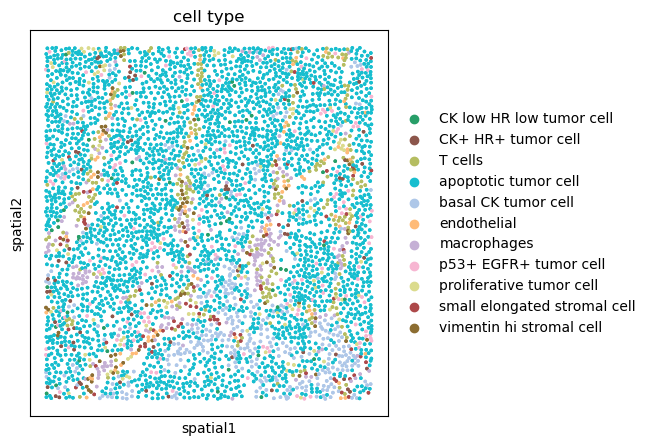

In [5]:
sq.pl.spatial_scatter(adata, shape=None, color="cell type", size=10)

In [ ]:
import hydra
import rootutils
from omegaconf import OmegaConf

rootutils.setup_root("..", indicator=".project-root", pythonpath=True)

from src.data.spatial_omics_datamodule import SpatialOmicsDataModule

with hydra.initialize_config_dir(
    config_dir="/Users/lovrorabuzin/Projects/grass-mil_unification/grass-mil/configs",
    version_base="1.3",
):
    cfg = hydra.compose(
        config_name="train",
        overrides=[
            "experiment=debug",
            "hydra/job_logging=stdout",
            "hydra/hydra_logging=none",
        ],
    )

print(OmegaConf.to_yaml(cfg))

dm: SpatialOmicsDataModule = hydra.utils.instantiate(cfg.data)
dm.prepare_data()
dm.setup()

dataset = dm.train_dataloader().dataset
print(f"Num graphs: {len(dataset)}")
print(dataset[0])


task_name: train
tags:
- dev
train: true
test: true
ckpt_path: null
seed: null
data:
  _target_: src.data.spatial_omics_datamodule.SpatialOmicsDataModule
  data_dir: ${paths.data_dir}
  raw_manifest_path: ${paths.data_dir}/dummy/manifest.csv
  processed_dir: ${paths.data_dir}/dummy/processed
  batch_size: 1
  num_workers: 0
  pin_memory: false
  coord_scale_um: 1.0
  sample_unit: tile
  reducer_scope: sample
  keep_raw_molecular: false
  force_precompute: false
  min_cells: 10
  use_molecular_features: true
  categorical_features:
    include_labels:
    - cell type
  split:
    train_val_test_split:
    - 1.0
    - 0.0
    - 0.0
    split_by: sample
  manifest:
    sample_id: sample_id
    input_path: input_path
    input_type: input_type
    region_id: region_id
    polygons_path: polygons_path
  csv:
    sep: ','
    coord_columns:
    - x
    - 'y'
    cell_id_column: cell_id
    categorical_label_columns: []
    molecular_columns: null
  h5ad:
    coord_source: obsm
    coord_key:

/Users/lovrorabuzin/Projects/grass-mil_unification/grass-mil/src/data/components/datasets.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(entry.path)


In [8]:
dataset[0]

Data(
  x=[762, 34],
  edge_index=[2, 4536],
  pos=[762, 2],
  edge_attr=[4536, 2],
  edge_attr_names=[2],
  categorical_index=[762, 1],
  categorical_labels=[1],
  categorical_slices={ cell type=0 },
  sample_id='s1',
  region_id='r1',
  patch_id='s1_r1_patch_0'
)

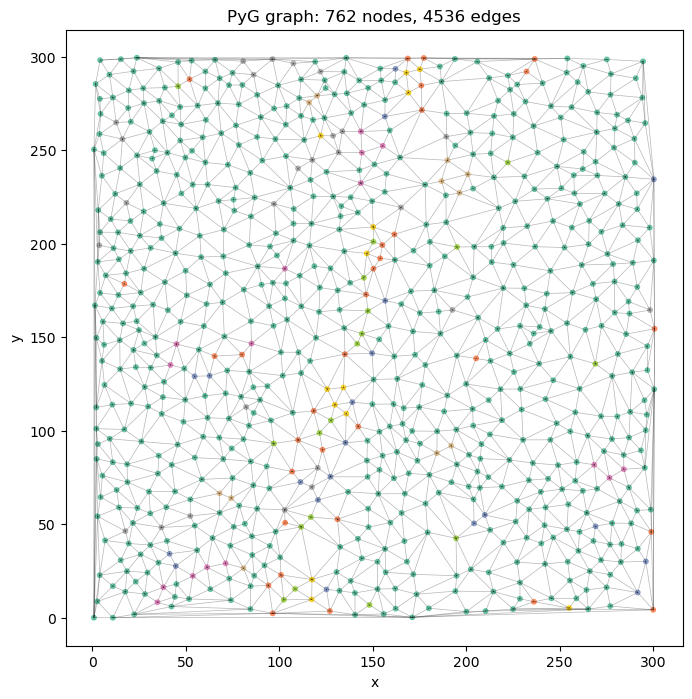

In [ ]:
import matplotlib.pyplot as plt
import torch


def plot_pyg_spatial(data, node_color=None, node_size=10, edge_alpha=0.15, edge_lw=0.5):
    pos = data.pos.detach().cpu()
    ei = data.edge_index.detach().cpu()

    x, y = pos[:, 0].numpy(), pos[:, 1].numpy()

    y = y.max() - y

    plt.figure(figsize=(8, 8))

    # edges
    for s, t in ei.t().tolist():
        plt.plot(
            [x[s], x[t]], [y[s], y[t]], color="k", alpha=edge_alpha, linewidth=edge_lw
        )

    # nodes
    if node_color is None:
        plt.scatter(x, y, s=node_size, c="tab:blue")
    else:
        c = (
            node_color.detach().cpu().numpy()
            if isinstance(node_color, torch.Tensor)
            else node_color
        )
        plt.scatter(x, y, s=node_size, c=c, cmap="Set2")

    plt.gca().set_aspect("equal", adjustable="box")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"PyG graph: {data.num_nodes} nodes, {data.num_edges} edges")
    plt.show()


# example:
d = dataset[0]
plot_pyg_spatial(d, node_color=d.categorical_index)